# Sample 1 (2008) — Medication Refill & Adherence Exploratory Analysis

This notebook explores possible relationships between patient characteristics, medication use, cost, and refill behavior using **CMS DE-SynPUF Sample 1 only**, restricted to **calendar year 2008** prescription events and the **2008 Beneficiary Summary** for demographics.


In [45]:
%matplotlib inline
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- Paths (Sample 1 only) ---
_cwd = Path.cwd().resolve()
if (_cwd / "data" / "CMS" / "Sample 1").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data" / "CMS" / "Sample 1").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

SAMPLE_1_DIR = PROJECT_ROOT / "data" / "CMS" / "Sample 1"
BENE_PATH = SAMPLE_1_DIR / "DE1_0_2008_Beneficiary_Summary_File_Sample_1 2.csv"
PDE_PATH = SAMPLE_1_DIR / "DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv"

PATIENT_ID = "DESYNPUF_ID"
CONDITION_COLS = [
    "SP_ALZHDMTA", "SP_CHF", "SP_CHRNKIDN", "SP_CNCR", "SP_COPD",
    "SP_DEPRESSN", "SP_DIABETES", "SP_ISCHMCHT", "SP_OSTEOPRS",
    "SP_RA_OA", "SP_STRKETIA",
]
CONDITION_LABELS = {
    "SP_ALZHDMTA": "Alzheimer's",
    "SP_CHF": "CHF",
    "SP_CHRNKIDN": "Chronic kidney disease",
    "SP_CNCR": "Cancer",
    "SP_COPD": "COPD",
    "SP_DEPRESSN": "Depression",
    "SP_DIABETES": "Diabetes",
    "SP_ISCHMCHT": "Ischemic heart disease",
    "SP_OSTEOPRS": "Osteoporosis",
    "SP_RA_OA": "RA/Osteoarthritis",
    "SP_STRKETIA": "Stroke/TIA",
}
AGE_BIN_EDGES = [0, 60, 70, 80, 90, 101]
AGE_BIN_LABELS = ["Under 60", "60-69", "70-79", "80-89", "90+"]
REFILL_FREQ_LABELS = ["2-5", "6-20", "21-50", "51+"]




## 1. Load & filter — Sample 1, 2008 only

- **Beneficiary file:** 2008 Beneficiary Summary — Sample 1 patients only.
- **Prescription events:** PDE file filtered to `SRVC_DT` in **calendar year 2008** only.
- **Refill filter:** Patients with **0 or 1 refill** in 2008 are **removed here**; all downstream analysis uses **>=2 refills** only.
- **No** Sample 2+ data and **no** other years' beneficiary files are used.


In [46]:
beneficiary = pd.read_csv(BENE_PATH, dtype={PATIENT_ID: str})
pde_all = pd.read_csv(
    PDE_PATH,
    dtype={PATIENT_ID: str, "PDE_ID": str, "PROD_SRVC_ID": str},
    low_memory=False,
)

pde_all["SRVC_DT"] = pd.to_datetime(pde_all["SRVC_DT"].astype(str), format="%Y%m%d", errors="coerce")
pde = pde_all[pde_all["SRVC_DT"].dt.year == 2008].copy()

# Refill counts per patient (2008 PDE rows)
refill_counts = pde.groupby(PATIENT_ID, observed=True).size()
bene_refills = beneficiary[PATIENT_ID].map(refill_counts).fillna(0).astype(int)

n_excl_0 = (bene_refills == 0).sum()
n_excl_1 = (bene_refills == 1).sum()
keep_ids = set(beneficiary.loc[bene_refills >= 2, PATIENT_ID])

beneficiary = beneficiary[beneficiary[PATIENT_ID].isin(keep_ids)].copy()
pde = pde[pde[PATIENT_ID].isin(keep_ids)].copy()

print("=== Sample 1, 2008 cohort (>=2 refills) ===")
print(f"Excluded 0-fill patients: {n_excl_0:,}")
print(f"Excluded 1-fill patients: {n_excl_1:,}")
print(f"Beneficiary rows kept:     {len(beneficiary):,}")
print(f"PDE rows kept (2008):      {len(pde):,}")
kept_refills = refill_counts[refill_counts.index.isin(keep_ids)]
print(f"Min refills per patient:   {kept_refills.min()}")
print(f"Max refills per patient:   {kept_refills.max()}")



=== Sample 1, 2008 cohort (>=2 refills) ===
Excluded 0-fill patients: 43,504
Excluded 1-fill patients: 4,029
Beneficiary rows kept:     68,819
PDE rows kept (2008):      1,991,200
Min refills per patient:   2
Max refills per patient:   144


## 2. Data quality checks


In [47]:
print("--- Missing values ---")
print("Beneficiary:")
print(beneficiary.isna().sum().sort_values(ascending=False).head(8))
print("\nPDE (2008):")
print(pde.isna().sum())

dup_bene = beneficiary.duplicated(subset=[PATIENT_ID]).sum()
dup_pde = pde.duplicated(subset=["PDE_ID"]).sum()
print(f"\nDuplicate {PATIENT_ID} in beneficiary: {dup_bene}")
print(f"Duplicate PDE_ID in PDE: {dup_pde}")

print("\n--- Data types ---")
print(beneficiary.dtypes.head(12))
print(pde.dtypes)

# Numeric coercion for cost / days supply
for col in ["TOT_RX_CST_AMT", "PTNT_PAY_AMT", "DAYS_SUPLY_NUM", "QTY_DSPNSD_NUM"]:
    pde[col] = pd.to_numeric(pde[col], errors="coerce")

invalid_dates = pde["SRVC_DT"].isna().sum()
print(f"\nInvalid SRVC_DT after parsing: {invalid_dates}")


--- Missing values ---
Beneficiary:
BENE_DEATH_DT    68049
DESYNPUF_ID          0
SP_DEPRESSN          0
BENRES_CAR           0
MEDREIMB_CAR         0
PPPYMT_OP            0
BENRES_OP            0
MEDREIMB_OP          0
dtype: int64

PDE (2008):
DESYNPUF_ID       0
PDE_ID            0
SRVC_DT           0
PROD_SRVC_ID      0
QTY_DSPNSD_NUM    0
DAYS_SUPLY_NUM    0
PTNT_PAY_AMT      0
TOT_RX_CST_AMT    0
dtype: int64

Duplicate DESYNPUF_ID in beneficiary: 0
Duplicate PDE_ID in PDE: 0

--- Data types ---
DESYNPUF_ID                     str
BENE_BIRTH_DT                 int64
BENE_DEATH_DT               float64
BENE_SEX_IDENT_CD             int64
BENE_RACE_CD                  int64
BENE_ESRD_IND                   str
SP_STATE_CODE                 int64
BENE_COUNTY_CD                int64
BENE_HI_CVRAGE_TOT_MONS       int64
BENE_SMI_CVRAGE_TOT_MONS      int64
BENE_HMO_CVRAGE_TOT_MONS      int64
PLAN_CVRG_MOS_NUM             int64
dtype: object
DESYNPUF_ID                  str
PDE_ID        

## 3. Feature engineering & assumptions

> **Note:** The next code cell may take 1–2 minutes (on-time refill and 90-day PDC calculations).

| Variable | Definition |
|----------|------------|
| `n_refills` | Count of PDE rows per patient in **2008** (includes all fills, all drugs) |
| `avg_rx_cost` / `total_rx_cost` | Mean / sum of `TOT_RX_CST_AMT` per patient in 2008 |
| `avg_days_supply` / `total_days_supply` | Mean / sum of `DAYS_SUPLY_NUM` per patient in 2008 |
| `n_unique_drugs` | Distinct `PROD_SRVC_ID` per patient in 2008 |
| `n_conditions` | Count of `SP_*` flags equal to **1** (yes) on 2008 beneficiary row |
| `chronic_status` | **1** if `n_conditions >= 1`, else **0** |
| `age_2008` | `2008 - birth_year`, where birth year = `BENE_BIRTH_DT // 10000` (year-only approximation) |
| `on_time_refill_rate` | For patient–drug pairs with **2+ fills** in 2008: share of consecutive fills where gap ≤ prior `DAYS_SUPLY_NUM` + **14-day grace** |
| `pdc_90d` | Proportion of days covered by fills in the **first 90 days of 2008** (cap overlap at 90), per patient across all fills |

**Cohort:** 0- and 1-fill patients were already removed in **Load & filter**; every patient here has **>=2 refills**.

**Assumptions:** CMS `SP_*` values use 1 = yes, 2 = no. Gender: `BENE_SEX_IDENT_CD` 1 = Male, 2 = Female. Refill ≈ one PDE claim row (not a dedicated refill flag). Synthetic DE-SynPUF NDCs may not match real-world drugs.


In [48]:
# Demographics from 2008 beneficiary summary
beneficiary["age_2008"] = 2008 - (pd.to_numeric(beneficiary["BENE_BIRTH_DT"], errors="coerce") // 10000)
beneficiary["n_conditions"] = (beneficiary[CONDITION_COLS] == 1).sum(axis=1)
beneficiary["chronic_status"] = (beneficiary["n_conditions"] >= 1).astype(int)
beneficiary["chronic_label"] = beneficiary["chronic_status"].map({0: "Non-chronic (0)", 1: "Chronic (1)"})
beneficiary["sex_label"] = beneficiary["BENE_SEX_IDENT_CD"].map({1: "Male", 2: "Female"})

# Patient-level PDE aggregates (2008 fills; cohort already >=2 refills)
pde_agg = pde.groupby(PATIENT_ID, observed=True).agg(
    n_refills=(PATIENT_ID, "size"),
    avg_rx_cost=("TOT_RX_CST_AMT", "mean"),
    total_rx_cost=("TOT_RX_CST_AMT", "sum"),
    avg_days_supply=("DAYS_SUPLY_NUM", "mean"),
    total_days_supply=("DAYS_SUPLY_NUM", "sum"),
    n_unique_drugs=("PROD_SRVC_ID", "nunique"),
).reset_index()

patients = beneficiary.merge(pde_agg, on=PATIENT_ID, how="left")
fill_cols = ["n_refills", "avg_rx_cost", "total_rx_cost", "avg_days_supply", "total_days_supply", "n_unique_drugs"]
for c in fill_cols:
    patients[c] = patients[c].fillna(0)
patients["n_refills"] = patients["n_refills"].astype(int)

patients["refill_freq_group"] = pd.cut(
    patients["n_refills"],
    bins=[1, 5, 20, 50, np.inf],
    labels=REFILL_FREQ_LABELS,
)

# --- 90-day refill timeliness (patient-drug pairs with 2+ fills) ---
pde_sorted = pde.sort_values([PATIENT_ID, "PROD_SRVC_ID", "SRVC_DT"])

def pair_on_time_rate(group):
    if len(group) < 2:
        return np.nan
    ok = []
    for i in range(1, len(group)):
        prev, curr = group.iloc[i - 1], group.iloc[i]
        gap = (curr["SRVC_DT"] - prev["SRVC_DT"]).days
        allowed = max(prev["DAYS_SUPLY_NUM"], 1) + 14
        ok.append(gap <= allowed)
    return float(np.mean(ok))

pair_scores = (
    pde_sorted.groupby([PATIENT_ID, "PROD_SRVC_ID"], observed=True)
    .apply(pair_on_time_rate, include_groups=False)
    .rename("on_time_rate")
    .reset_index()
)
patient_on_time = pair_scores.groupby(PATIENT_ID, observed=True)["on_time_rate"].mean().rename("on_time_refill_rate")
patients = patients.merge(patient_on_time, on=PATIENT_ID, how="left")

# --- PDC in first 90 days of 2008 (vectorized per patient) ---
start_2008 = pd.Timestamp("2008-01-01")
pde_90 = pde[pde["SRVC_DT"] <= pd.Timestamp("2008-03-31")].copy()
pde_90["start_day"] = (pde_90["SRVC_DT"] - start_2008).dt.days.clip(lower=0, upper=90)
pde_90["end_day"] = (pde_90["start_day"] + pde_90["DAYS_SUPLY_NUM"].fillna(0)).clip(upper=91)

def pdc_first_90(group):
    covered = np.zeros(91, dtype=bool)
    for s, e in zip(group["start_day"], group["end_day"]):
        covered[int(s):int(e)] = True
    return covered.sum() / 90.0

pdc = pde_90.groupby(PATIENT_ID, observed=True).apply(pdc_first_90, include_groups=False).rename("pdc_90d")
patients = patients.merge(pdc, on=PATIENT_ID, how="left")

print("Analysis cohort (>=2 refills, filtered in Load & filter):")
print(patients[["age_2008", "n_refills", "n_conditions", "total_rx_cost", "on_time_refill_rate", "pdc_90d"]].describe().round(2))
print(f"\nPatients: {len(patients):,} | PDE rows: {len(pde):,}")
print(f"Min refills: {patients['n_refills'].min()} | Max refills: {patients['n_refills'].max()}")



Analysis cohort (>=2 refills, filtered in Load & filter):
       age_2008  n_refills  n_conditions  total_rx_cost  on_time_refill_rate  \
count  68819.00   68819.00      68819.00       68819.00               492.00   
mean      71.75      28.93          2.53        1775.94                 0.24   
std       13.06      20.48          2.55        1751.49                 0.43   
min       25.00       2.00          0.00           0.00                 0.00   
25%       66.00      14.00          0.00         470.00                 0.00   
50%       73.00      26.00          2.00        1210.00                 0.00   
75%       80.00      40.00          4.00        2510.00                 0.00   
max       99.00     144.00         11.00       14100.00                 1.00   

        pdc_90d  
count  54430.00  
mean       0.60  
std        0.28  
min        0.00  
25%        0.37  
50%        0.64  
75%        0.84  
max        1.01  

Patients: 68,819 | PDE rows: 1,991,200
Min refills: 2 | Ma

## 4. Histograms

Cohort: **>=2 refills** (0- and 1-fill patients removed in Load & filter).


Patient Age (2008) (>=2 refills): median=73.0, skew=-0.84 (left-skewed), ~4.4% IQR outliers
Refills per Patient (2008) (>=2 refills): median=26.0, skew=1.10 (right-skewed), ~2.2% IQR outliers
Chronic Conditions per Patient (>=2 refills): median=2.0, skew=0.75 (right-skewed), ~0.0% IQR outliers
Days Supply (fill-level) (>=2 refills): median=30.0, skew=1.85 (right-skewed), ~27.5% IQR outliers
Medication Cost (fill-level) (>=2 refills): median=20.0, skew=3.00 (right-skewed), ~7.2% IQR outliers


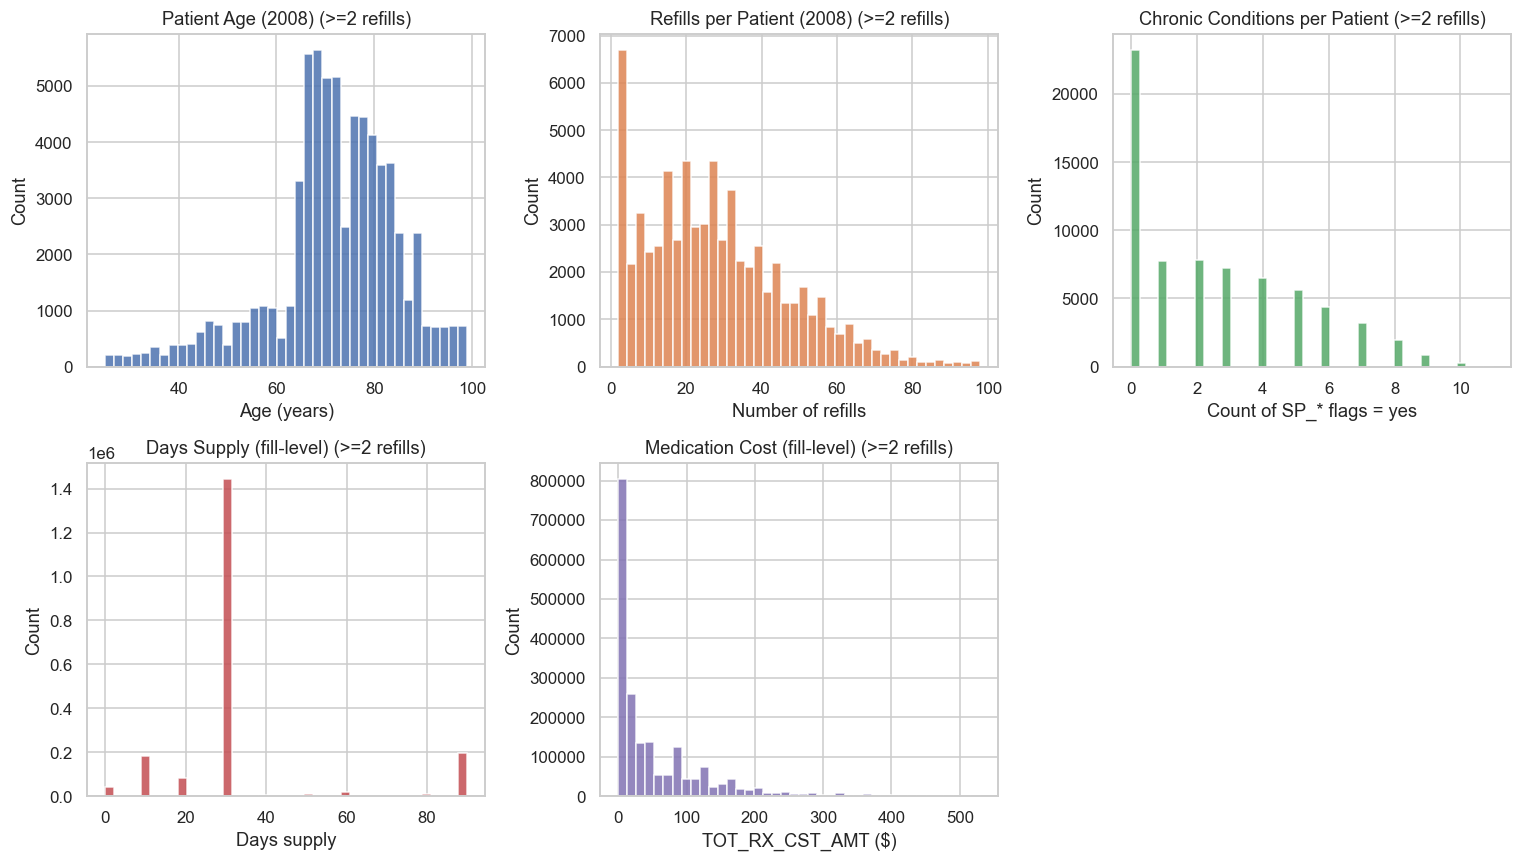

In [49]:
def describe_distribution(series, name):
    s = series.dropna()
    skew = stats.skew(s)
    skew_label = "approximately symmetric" if abs(skew) < 0.5 else ("right-skewed" if skew > 0 else "left-skewed")
    q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100
    print(f"{name}: median={med:.1f}, skew={skew:.2f} ({skew_label}), ~{outliers:.1f}% IQR outliers")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
GRAPH_NOTE = " (>=2 refills)"

hist_specs = [
    (patients["age_2008"], "Patient Age (2008)" + GRAPH_NOTE, "Age (years)", "#4C72B0"),
    (patients["n_refills"], "Refills per Patient (2008)" + GRAPH_NOTE, "Number of refills", "#DD8452"),
    (patients["n_conditions"], "Chronic Conditions per Patient" + GRAPH_NOTE, "Count of SP_* flags = yes", "#55A868"),
    (pde["DAYS_SUPLY_NUM"], "Days Supply (fill-level)" + GRAPH_NOTE, "Days supply", "#C44E52"),
    (pde["TOT_RX_CST_AMT"], "Medication Cost (fill-level)" + GRAPH_NOTE, "TOT_RX_CST_AMT ($)", "#8172B3"),
]

for ax, (data, title, xlabel, color) in zip(axes, hist_specs):
    plot_data = data.dropna()
    if title.startswith("Medication Cost"):
        plot_data = plot_data[plot_data <= plot_data.quantile(0.99)]
    if "Refills per Patient" in title:
        plot_data = plot_data[plot_data <= plot_data.quantile(0.99)]
    ax.hist(plot_data, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    describe_distribution(data, title)

axes[-1].axis("off")
plt.tight_layout()
plt.show()



**Histogram takeaways:** Age is mildly right-skewed (older Medicare cohort). Refills and medication cost are strongly right-skewed with long upper tails (outliers). Days supply clusters around 30-day fills. Chronic condition counts are discrete and heavily concentrated at 0–2 conditions.


## 5. Scatter plots


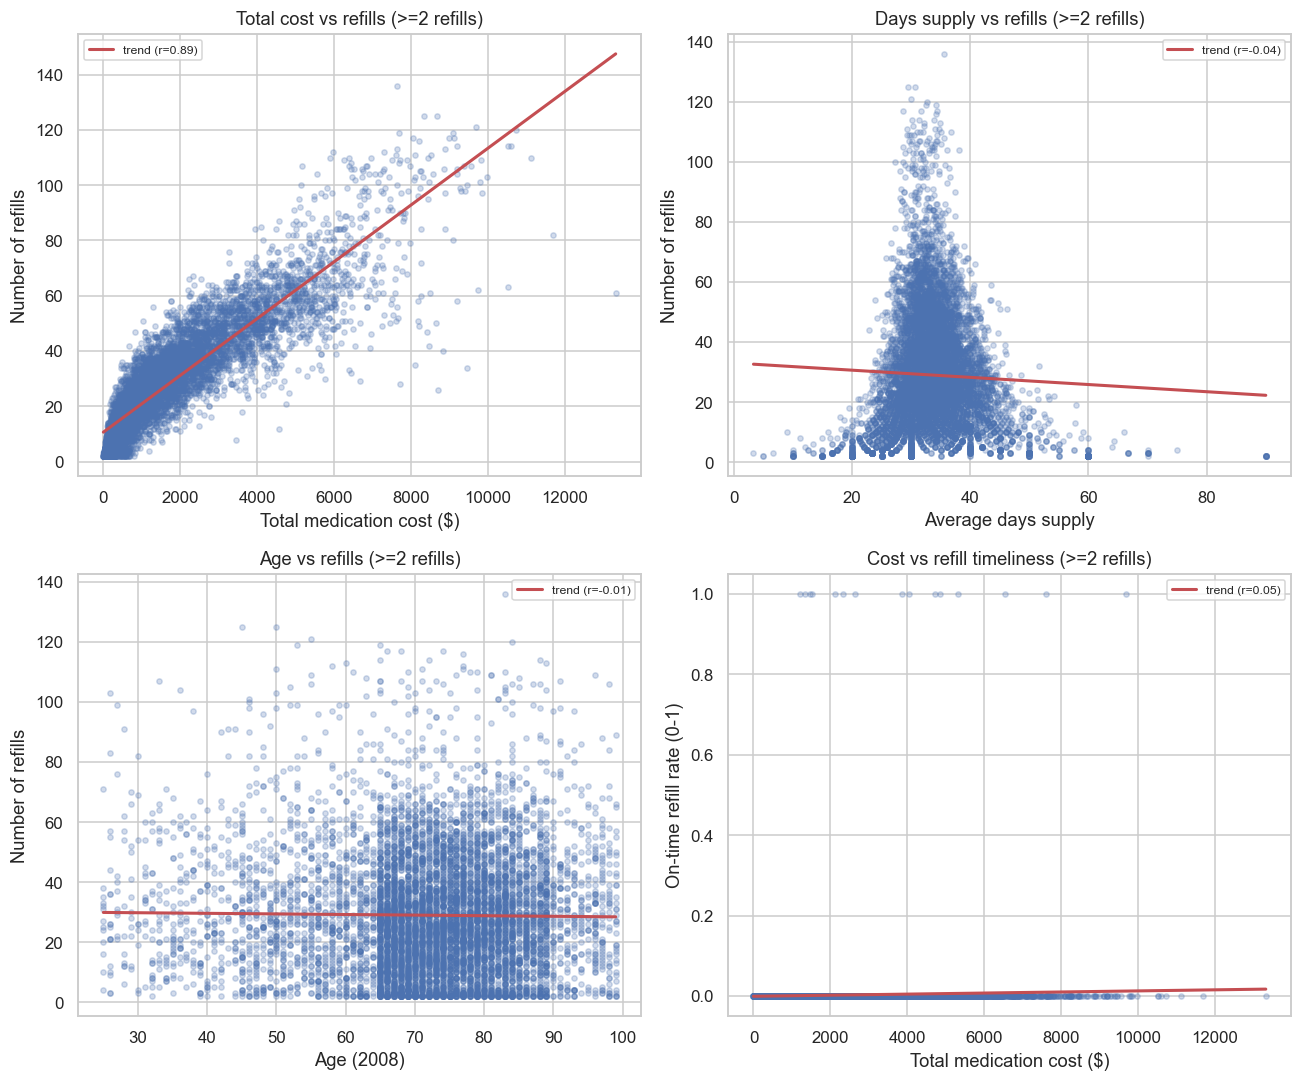

Scatter interpretations (>=2 refill cohort):
  Total cost vs refills: Pearson r = 0.899
  Avg days supply vs refills: Pearson r = -0.040
  Age vs refills: Pearson r = -0.008
  Total cost vs on-time refill rate: Pearson r = -0.020


In [50]:
def scatter_with_trend(ax, x, y, xlabel, ylabel, title, log_x=False, log_y=False, sample_n=8000):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(df) > sample_n:
        df = df.sample(sample_n, random_state=42)
    xv, yv = df["x"], df["y"]
    if log_x:
        mask = xv > 0
        xv, yv = xv[mask], yv[mask]
    if log_y:
        mask = yv > 0
        xv, yv = xv[mask], yv[mask]
    ax.scatter(xv, yv, alpha=0.25, s=12, color="#4C72B0")
    if len(xv) > 2:
        slope, intercept, r, p, _ = stats.linregress(xv, yv)
        xs = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xs, intercept + slope * xs, color="#C44E52", lw=2, label=f"trend (r={r:.2f})")
        ax.legend(loc="best", fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scatter_with_trend(
    axes[0, 0], patients["total_rx_cost"], patients["n_refills"],
    "Total medication cost ($)", "Number of refills",
    "Total cost vs refills (>=2 refills)",
)
scatter_with_trend(
    axes[0, 1], patients["avg_days_supply"], patients["n_refills"],
    "Average days supply", "Number of refills",
    "Days supply vs refills (>=2 refills)",
)
scatter_with_trend(
    axes[1, 0], patients["age_2008"], patients["n_refills"],
    "Age (2008)", "Number of refills",
    "Age vs refills (>=2 refills)",
)
scatter_with_trend(
    axes[1, 1], patients["total_rx_cost"], patients["on_time_refill_rate"].fillna(0),
    "Total medication cost ($)", "On-time refill rate (0-1)",
    "Cost vs refill timeliness (>=2 refills)",
)

plt.tight_layout()
plt.show()

print("Scatter interpretations (>=2 refill cohort):")
for x, y, label in [
    ("total_rx_cost", "n_refills", "Total cost vs refills"),
    ("avg_days_supply", "n_refills", "Avg days supply vs refills"),
    ("age_2008", "n_refills", "Age vs refills"),
    ("total_rx_cost", "on_time_refill_rate", "Total cost vs on-time refill rate"),
]:
    sub = patients[[x, y]].dropna()
    r = sub[x].corr(sub[y])
    print(f"  {label}: Pearson r = {r:.3f}")



**Scatter takeaways:** Total cost vs refills shows a **strong positive** cloud (more fills → higher total spend). Average days supply vs refills is **moderately positive**. Age vs refills is **very weak**. Cost vs on-time refill rate is **weak** — higher spend does not clearly imply better timeliness.


## 6. Box-and-whisker plots


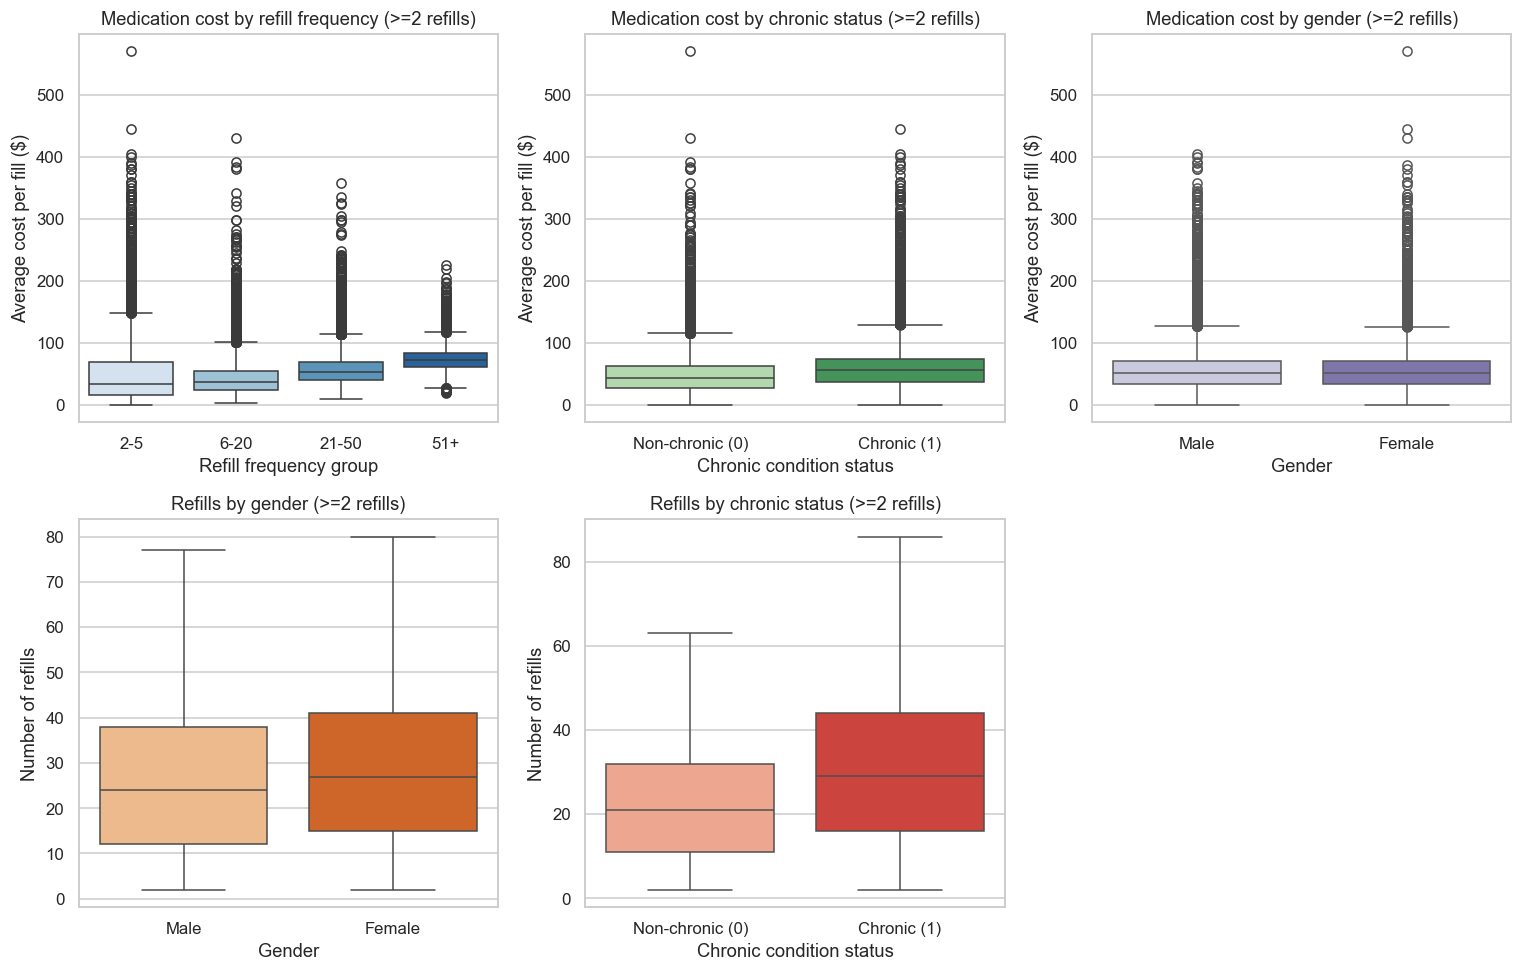

Group medians — avg cost per fill:
refill_freq_group
2-5      33.333333
6-20     36.315789
21-50    53.333333
51+      72.222222
Name: avg_rx_cost, dtype: float64

Group medians — refills:
sex_label
Female    27.0
Male      24.0
Name: n_refills, dtype: float64
chronic_label
Chronic (1)        29.0
Non-chronic (0)    21.0
Name: n_refills, dtype: float64


In [51]:
# patients and pde already filtered to >=2 refills in Load & filter (cell 3)
plot_patients = patients

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

sns.boxplot(data=plot_patients, x="refill_freq_group", y="avg_rx_cost", order=REFILL_FREQ_LABELS, ax=axes[0], palette="Blues")
axes[0].set_title("Medication cost by refill frequency (>=2 refills)")
axes[0].set_xlabel("Refill frequency group")
axes[0].set_ylabel("Average cost per fill ($)")

sns.boxplot(data=plot_patients, x="chronic_label", y="avg_rx_cost", order=["Non-chronic (0)", "Chronic (1)"], ax=axes[1], palette="Greens")
axes[1].set_title("Medication cost by chronic status (>=2 refills)")
axes[1].set_xlabel("Chronic condition status")
axes[1].set_ylabel("Average cost per fill ($)")

sns.boxplot(data=plot_patients, x="sex_label", y="avg_rx_cost", order=["Male", "Female"], ax=axes[2], palette="Purples")
axes[2].set_title("Medication cost by gender (>=2 refills)")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Average cost per fill ($)")

sns.boxplot(data=plot_patients, x="sex_label", y="n_refills", order=["Male", "Female"], ax=axes[3], palette="Oranges", showfliers=False)
axes[3].set_title("Refills by gender (>=2 refills)")
axes[3].set_xlabel("Gender")
axes[3].set_ylabel("Number of refills")

sns.boxplot(data=plot_patients, x="chronic_label", y="n_refills", order=["Non-chronic (0)", "Chronic (1)"], ax=axes[4], palette="Reds", showfliers=False)
axes[4].set_title("Refills by chronic status (>=2 refills)")
axes[4].set_xlabel("Chronic condition status")
axes[4].set_ylabel("Number of refills")

axes[5].axis("off")
plt.tight_layout()
plt.show()

print("Group medians — avg cost per fill:")
print(plot_patients.groupby("refill_freq_group", observed=True)["avg_rx_cost"].median())
print("\nGroup medians — refills:")
print(plot_patients.groupby("sex_label")["n_refills"].median())
print(plot_patients.groupby("chronic_label")["n_refills"].median())



**Box plot takeaways:** Higher refill-frequency groups show higher typical costs per fill. Chronic patients have higher median refills (~14 vs ~2) and slightly higher cost per fill. Females show higher median refills than males. All cost distributions have upper-tail outliers.


## 7. Bubble chart — grouped by age, cost, and chronic condition

### Why change from the old chart?
The previous bubble chart plotted **one dot per patient** (age on X, avg cost on Y, size = that patient's refills). That is hard to read with ~70k points and only used a **binary** chronic flag (any vs none).

### Steps to build the new chart

1. **Start with the analysis cohort** — patients with **>=2 refills** in 2008 (already filtered in Load & filter).

2. **Bin age (X-axis)** — group patients into decade-style bins aligned with your example:
   - Under 60, **60-69**, **70-79**, 80-89, 90+

3. **Bin average medication cost (Y-axis)** — split `avg_rx_cost` (mean cost per fill) into **5 quintile bins** (e.g. `$0-$33`, `$33-$51`, …) so cost is grouped, not plotted as a raw per-patient dollar value.

4. **Define chronic condition membership (color)** — use each CMS `SP_*` flag separately (`1` = yes). A patient with ischemic heart disease **and** diabetes appears in **both** the "Ischemic heart disease" group and the "Diabetes" group when those bubbles are computed.

5. **Aggregate within each cell** — for every combination of `(condition, age bin, cost bin)`:
   - **Bubble size** = **mean number of refills** for all patients in that cell who have that condition flag
   - Track **n patients** in the cell; hide bubbles with fewer than 20 patients (stable averages)

6. **Plot** — one bubble per aggregated cell; color = condition; small horizontal jitter when multiple conditions share the same age/cost bin.

### How to read it
- **Larger bubble** → that age + cost + condition subgroup has a **higher average refill count**
- **Same patient in multiple color groups** is intentional — comorbidity is preserved
- Compare **across colors** at the same age/cost position to see condition-specific refill patterns


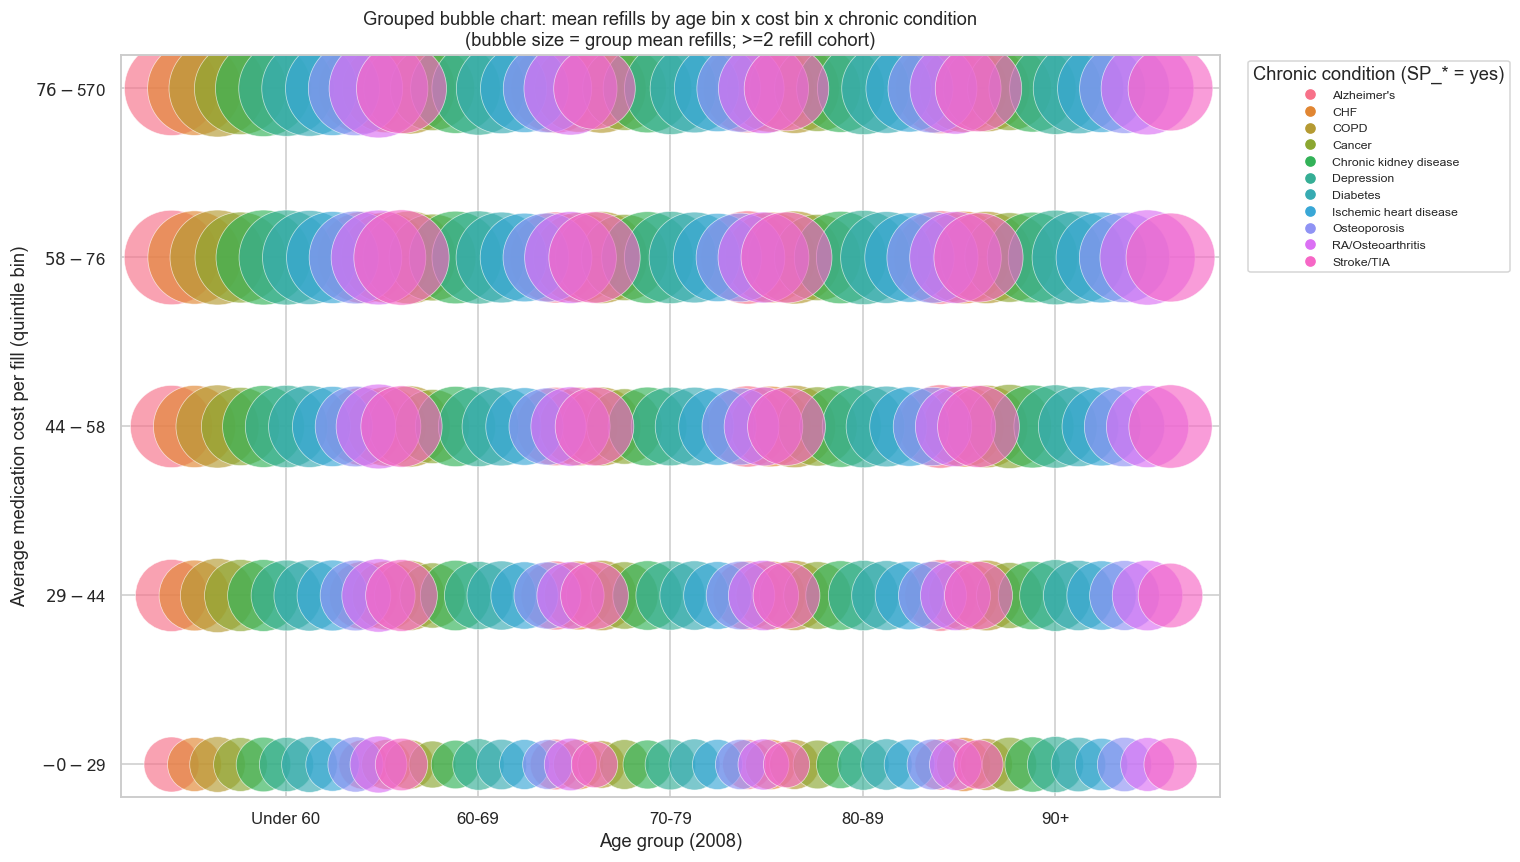

Ischemic heart disease, ages 60-69 — mean refills by cost bin:


,cost_bin_label,mean_refills,n_patients
183,$58-$76,42.01,1536
184,$76-$570,41.51,1624
182,$44-$58,32.13,1423
181,$29-$44,24.22,1172
180,$-0-$29,13.36,1130



Aggregated bubbles plotted: 275 (min 20 patients per cell)
Sample — highest mean refills across all groups:


,condition,age_bin,cost_bin_label,mean_refills,n_patients
229,RA/Osteoarthritis,Under 60,$76-$570,52.27,440
54,COPD,Under 60,$76-$570,50.42,487
104,Chronic kidney disease,Under 60,$76-$570,49.42,552
129,Depression,Under 60,$76-$570,48.88,1021
154,Diabetes,Under 60,$76-$570,48.81,1258


In [52]:
# --- Step 1: patient-level bins (age + avg cost) ---
bubble_base = patients[[PATIENT_ID, "age_2008", "avg_rx_cost", "n_refills"] + CONDITION_COLS].copy()

bubble_base["age_bin"] = pd.cut(
    bubble_base["age_2008"],
    bins=AGE_BIN_EDGES,
    labels=AGE_BIN_LABELS,
    right=False,
)
bubble_base["cost_bin"] = pd.qcut(bubble_base["avg_rx_cost"], q=5, duplicates="drop")
bubble_base["cost_bin_label"] = bubble_base["cost_bin"].apply(
    lambda iv: f"${iv.left:.0f}-${iv.right:.0f}"
)

# --- Step 2: long format — one row per patient per condition flag = yes ---
cond_rows = []
for col in CONDITION_COLS:
    has_cond = bubble_base.loc[bubble_base[col] == 1].copy()
    has_cond["condition"] = CONDITION_LABELS[col]
    cond_rows.append(
        has_cond[[PATIENT_ID, "age_bin", "cost_bin", "cost_bin_label", "n_refills", "condition"]]
    )
cond_long = pd.concat(cond_rows, ignore_index=True)

# --- Step 3: aggregate — bubble size = mean refills per (condition x age bin x cost bin) ---
bubble_groups = (
    cond_long.groupby(["condition", "age_bin", "cost_bin", "cost_bin_label"], observed=True)
    .agg(mean_refills=("n_refills", "mean"), n_patients=(PATIENT_ID, "nunique"))
    .reset_index()
)
MIN_N = 20
bubble_groups = bubble_groups[bubble_groups["n_patients"] >= MIN_N].copy()

# Numeric positions for plotting
age_x = {label: i for i, label in enumerate(AGE_BIN_LABELS)}
cost_bins_sorted = sorted(bubble_groups["cost_bin"].unique(), key=lambda x: x.left)
cost_y = {cb: i for i, cb in enumerate(cost_bins_sorted)}
cost_labels_ordered = [
    bubble_groups.loc[bubble_groups["cost_bin"] == cb, "cost_bin_label"].iloc[0]
    for cb in cost_bins_sorted
]
bubble_groups["x_base"] = bubble_groups["age_bin"].astype(str).map(age_x)
bubble_groups["y_base"] = bubble_groups["cost_bin"].map(cost_y)

conditions = sorted(bubble_groups["condition"].unique())
cond_jitter = {c: (i - (len(conditions) - 1) / 2) * 0.12 for i, c in enumerate(conditions)}
bubble_groups["x"] = bubble_groups["x_base"] + bubble_groups["condition"].map(cond_jitter)

palette = sns.color_palette("husl", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

fig, ax = plt.subplots(figsize=(14, 8))
size_scale = 80

for _, row in bubble_groups.iterrows():
    ax.scatter(
        row["x"],
        row["y_base"],
        s=row["mean_refills"] * size_scale,
        alpha=0.65,
        c=[color_map[row["condition"]]],
        edgecolors="white",
        linewidths=0.5,
        label=row["condition"],
    )

# Legend: one entry per condition
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[c],
               markersize=8, label=c)
    for c in conditions
]
ax.legend(handles=handles, title="Chronic condition (SP_* = yes)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

ax.set_xticks(range(len(AGE_BIN_LABELS)))
ax.set_xticklabels(AGE_BIN_LABELS)
ax.set_yticks(range(len(cost_bins_sorted)))
ax.set_yticklabels(cost_labels_ordered)
ax.set_xlabel("Age group (2008)")
ax.set_ylabel("Average medication cost per fill (quintile bin)")
ax.set_title("Grouped bubble chart: mean refills by age bin x cost bin x chronic condition\n(bubble size = group mean refills; >=2 refill cohort)")
plt.tight_layout()
plt.show()

# Example: ischemic heart disease, ages 60-69
ihd_60s = bubble_groups[
    (bubble_groups["condition"] == "Ischemic heart disease")
    & (bubble_groups["age_bin"].astype(str) == "60-69")
].sort_values("mean_refills", ascending=False)
print("Ischemic heart disease, ages 60-69 — mean refills by cost bin:")
display(ihd_60s[["cost_bin_label", "mean_refills", "n_patients"]].round(2))

print(f"\nAggregated bubbles plotted: {len(bubble_groups):,} (min {MIN_N} patients per cell)")
print("Sample — highest mean refills across all groups:")
display(bubble_groups.nlargest(5, "mean_refills")[
    ["condition", "age_bin", "cost_bin_label", "mean_refills", "n_patients"]
].round(2))




**Bubble chart takeaways (grouped version):**

- Each bubble is a **summary of a subgroup**, not one patient — size = **average refills** for patients in that age bin, cost bin, and with that **specific** chronic flag.
- Patients with **multiple** conditions contribute to **multiple** colored bubbles (comorbidity preserved).
- Compare bubble sizes **within** a condition across age/cost bins, or **across** conditions at the same bin, to see where refill activity concentrates.
- Small groups (<20 patients) are omitted to avoid unstable averages.


## 8. Bar charts


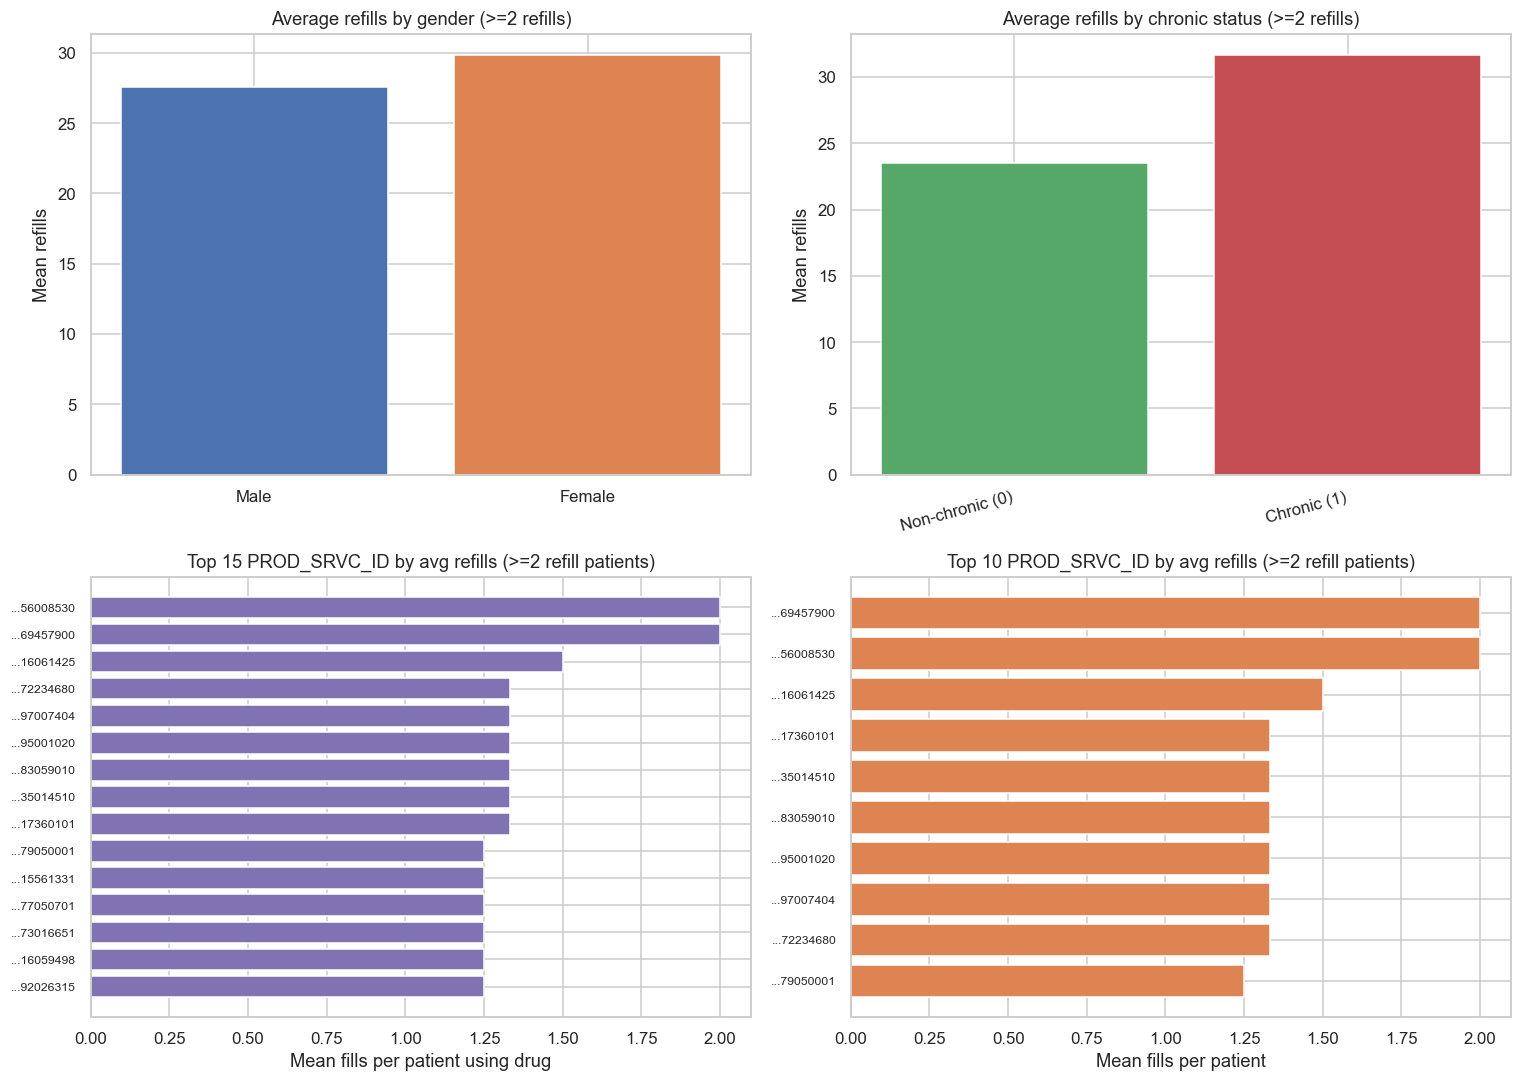

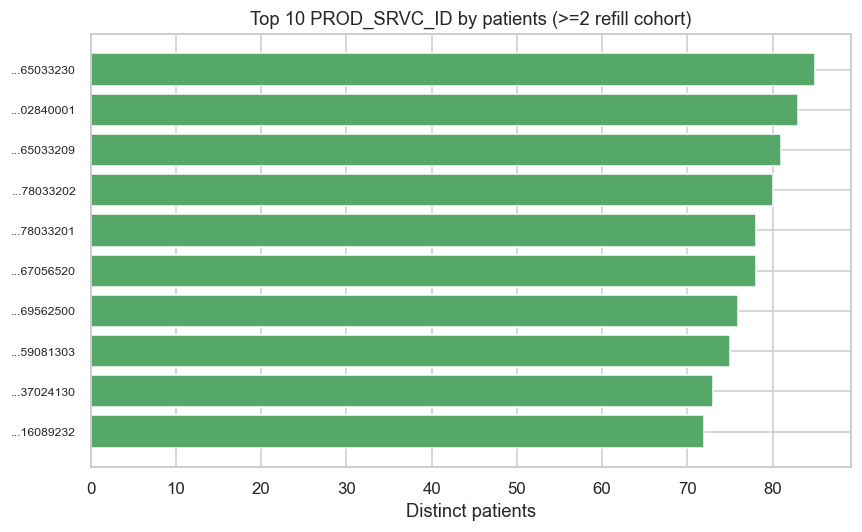

In [53]:
# Drug-level stats (2008 fills)
drug_patient_fills = pde.groupby(["PROD_SRVC_ID", PATIENT_ID], observed=True).size().reset_index(name="fills")
drug_avg_refills = drug_patient_fills.groupby("PROD_SRVC_ID", observed=True)["fills"].mean()
drug_n_patients = drug_patient_fills.groupby("PROD_SRVC_ID", observed=True)[PATIENT_ID].nunique()
top10_avg = drug_avg_refills.sort_values(ascending=False).head(10)
top10_n = drug_n_patients.sort_values(ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sex_means = patients.groupby("sex_label", observed=True)["n_refills"].mean().reindex(["Male", "Female"])
axes[0, 0].bar(sex_means.index, sex_means.values, color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Average refills by gender (>=2 refills)")
axes[0, 0].set_ylabel("Mean refills")

chronic_means = patients.groupby("chronic_label", observed=True)["n_refills"].mean().reindex(["Non-chronic (0)", "Chronic (1)"])
axes[0, 1].bar(range(len(chronic_means)), chronic_means.values, color=["#55A868", "#C44E52"])
axes[0, 1].set_xticks(range(len(chronic_means)))
axes[0, 1].set_xticklabels(chronic_means.index, rotation=15, ha="right")
axes[0, 1].set_title("Average refills by chronic status (>=2 refills)")
axes[0, 1].set_ylabel("Mean refills")

top15_drugs = drug_avg_refills.sort_values(ascending=False).head(15)
axes[1, 0].barh(range(len(top15_drugs)), top15_drugs.values, color="#8172B3")
axes[1, 0].set_yticks(range(len(top15_drugs)))
axes[1, 0].set_yticklabels([f"...{str(i)[-8:]}" for i in top15_drugs.index], fontsize=8)
axes[1, 0].invert_yaxis()
axes[1, 0].set_title("Top 15 PROD_SRVC_ID by avg refills (>=2 refill patients)")
axes[1, 0].set_xlabel("Mean fills per patient using drug")

top10_avg_plot = top10_avg.sort_values()
axes[1, 1].barh(range(len(top10_avg_plot)), top10_avg_plot.values, color="#DD8452")
axes[1, 1].set_yticks(range(len(top10_avg_plot)))
axes[1, 1].set_yticklabels([f"...{str(i)[-8:]}" for i in top10_avg_plot.index], fontsize=8)
axes[1, 1].set_title("Top 10 PROD_SRVC_ID by avg refills (>=2 refill patients)")
axes[1, 1].set_xlabel("Mean fills per patient")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
top10_n_plot = top10_n.sort_values()
ax.barh(range(len(top10_n_plot)), top10_n_plot.values, color="#55A868")
ax.set_yticks(range(len(top10_n_plot)))
ax.set_yticklabels([f"...{str(i)[-8:]}" for i in top10_n_plot.index], fontsize=8)
ax.set_title("Top 10 PROD_SRVC_ID by patients (>=2 refill cohort)")
ax.set_xlabel("Distinct patients")
plt.tight_layout()
plt.show()



## 9. Correlations


,comparison,method,correlation
0,Cost vs refills,spearman,0.920
1,Avg cost/fill vs refills,spearman,0.448
2,Age vs refills,spearman,0.012
3,Days supply vs refills,spearman,0.057
4,Chronic condition count vs refills,spearman,0.270


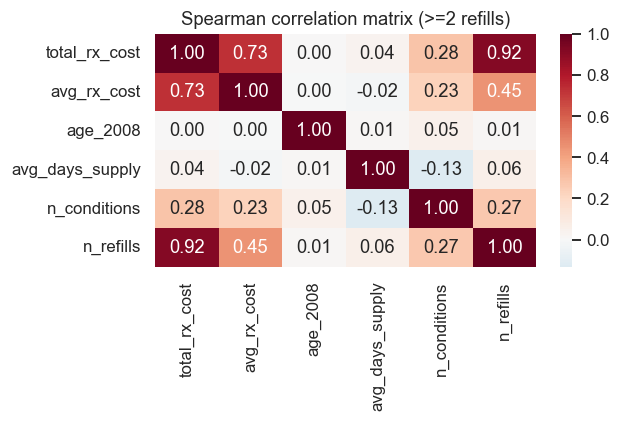

In [54]:
def pick_corr(x, y):
    """Use Spearman if either variable is skewed or has many zeros; else Pearson."""
    sx, sy = stats.skew(x.dropna()), stats.skew(y.dropna())
    if abs(sx) > 1 or abs(sy) > 1 or (x == 0).mean() > 0.2:
        method = "spearman"
    else:
        method = "pearson"
    r = x.corr(y, method=method)
    return method, r

corr_rows = []
for x, y, label in [
    ("total_rx_cost", "n_refills", "Cost vs refills"),
    ("avg_rx_cost", "n_refills", "Avg cost/fill vs refills"),
    ("age_2008", "n_refills", "Age vs refills"),
    ("avg_days_supply", "n_refills", "Days supply vs refills"),
    ("n_conditions", "n_refills", "Chronic condition count vs refills"),
]:
    method, r = pick_corr(patients[x], patients[y])
    corr_rows.append({"comparison": label, "method": method, "correlation": round(r, 3)})

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    patients[["total_rx_cost", "avg_rx_cost", "age_2008", "avg_days_supply", "n_conditions", "n_refills"]].corr(method="spearman"),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
)
ax.set_title("Spearman correlation matrix (>=2 refills)")
plt.tight_layout()
plt.show()



## 10. Research questions


In [55]:
research_summary = pd.DataFrame([
    {
        "Question": "1. Cost vs refills?",
        "Graphs used": "Scatter (total cost vs refills), box plot (cost by refill group)",
        "Pattern": "Strong positive association — more refills align with higher total spend",
        "Key stats": f"Spearman(total cost, refills) ≈ {patients['total_rx_cost'].corr(patients['n_refills'], method='spearman'):.2f} (>=2 refill cohort)",
        "Strength": "Strong for total cost; moderate for avg cost/fill",
    },
    {
        "Question": "2. Chronic conditions vs refills?",
        "Graphs used": "Histogram (# conditions), box plot, bar chart (chronic status), bubble chart",
        "Pattern": "Chronic patients may have more refills on average",
        "Key stats": f"Mean refills chronic=1: {patients.loc[patients.chronic_status==1,'n_refills'].mean():.1f} vs non-chronic: {patients.loc[patients.chronic_status==0,'n_refills'].mean():.1f}; r≈{patients['n_conditions'].corr(patients['n_refills'], method='spearman'):.2f}",
        "Strength": "Moderate",
    },
    {
        "Question": "3. Product ID vs refills?",
        "Graphs used": "Bar charts (top 10/15 PROD_SRVC_ID)",
        "Pattern": "Refill intensity varies by drug code among multi-fill patients",
        "Key stats": "Top drugs differ in avg fills/patient; cohort restricted to >=2 total refills",
        "Strength": "Moderate for specific drugs; weak as a single global predictor",
    },
    {
        "Question": "4. Age vs refills?",
        "Graphs used": "Histogram (age), scatter (age vs refills), bubble chart",
        "Pattern": "Little visible trend across age",
        "Key stats": f"Spearman(age, refills) ≈ {patients['age_2008'].corr(patients['n_refills'], method='spearman'):.2f}",
        "Strength": "Weak / unclear",
    },
    {
        "Question": "5. Gender vs refills?",
        "Graphs used": "Box plot, bar chart (mean refills by gender)",
        "Pattern": "Females may have higher refill counts than males",
        "Key stats": f"Mean refills Female: {patients.loc[patients.sex_label=='Female','n_refills'].mean():.1f} vs Male: {patients.loc[patients.sex_label=='Male','n_refills'].mean():.1f}",
        "Strength": "Moderate",
    },
])

display(research_summary)



,Question,Graphs used,Pattern,Key stats,Strength
0,1. Cost vs refills?,"Scatter (total cost vs refills), box plot (cos...",Strong positive association — more refills ali...,"Spearman(total cost, refills) ≈ 0.92 (>=2 refi...",Strong for total cost; moderate for avg cost/fill
1,2. Chronic conditions vs refills?,"Histogram (# conditions), box plot, bar chart ...",Chronic patients may have more refills on average,Mean refills chronic=1: 31.7 vs non-chronic: 2...,Moderate
2,3. Product ID vs refills?,Bar charts (top 10/15 PROD_SRVC_ID),Refill intensity varies by drug code among mul...,Top drugs differ in avg fills/patient; cohort ...,Moderate for specific drugs; weak as a single ...
3,4. Age vs refills?,"Histogram (age), scatter (age vs refills), bub...",Little visible trend across age,"Spearman(age, refills) ≈ 0.01",Weak / unclear
4,5. Gender vs refills?,"Box plot, bar chart (mean refills by gender)",Females may have higher refill counts than males,Mean refills Female: 29.9 vs Male: 27.6,Moderate


## 11. Conclusion

Among variables in **Sample 1, 2008** (**>=2 refills** only; 0- and 1-fill patients excluded from all graphs), **total medication cost** and **days supply** appear most strongly related to refill counts. **Chronic condition burden** and **female gender** appear associated with higher refill activity. **Age** shows a weak relationship. **Product ID** matters at the drug level but is not a single linear predictor at the patient level.

These are **exploratory associations only** — they do not establish causation.


## 12. Limitations

1. **Cohort filter:** 0- and 1-fill patients removed in Load & filter; analysis uses >=2 refills only.
2. **Scope:** Sample 1 only, 2008 calendar-year PDE events, 2008 beneficiary demographics.
3. **Synthetic data:** DE-SynPUF is simulated; patterns may not reflect real-world adherence.
4. **Refill proxy:** Each PDE row = one fill; no explicit refill flag.
5. **Adherence metrics:** 90-day on-time rate and PDC are simplified proxies.
6. **Confounding:** Part D enrollment, formulary, access not controlled.
7. **Correlation ≠ causation:** Higher cost may follow from more fills.
8. **Missing variables:** Only 11 CMS chronic flags; no direct adherence label.
